In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start_date='2026-02-28'
data=yf.download('XOM',start_date,auto_adjust=True)
data.columns=data.columns.droplevel(1)
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-02,154.220001,159.610001,153.029999,159.350006,31493100
2026-03-03,151.830002,156.050003,150.300003,155.429993,25198900
2026-03-04,149.820007,151.160004,147.860001,150.720001,16764800
2026-03-05,150.759995,152.330002,149.470001,151.000000,22969300
2026-03-06,151.210007,153.800003,149.960007,153.149994,21136400
2026-03-09,150.440002,153.889999,149.470001,152.020004,25532700
2026-03-10,148.130005,150.399994,147.699997,149.250000,19617600
2026-03-11,151.580002,151.809998,147.660004,147.990005,15297400
2026-03-12,153.529999,155.000000,151.630005,152.270004,26054000


I want to buy

In [3]:
#build a new dataframe from raw data
df=pd.DataFrame({
    "Price":data['Close']
})
df.iloc[0,0]=data.iloc[0,1] #I bought 1,000 shares XOM at Highest price at the first day after market opened
df

,Price
Date,
2026-03-02,159.610001
2026-03-03,151.830002
2026-03-04,149.820007
2026-03-05,150.759995
2026-03-06,151.210007
2026-03-09,150.440002
2026-03-10,148.130005
2026-03-11,151.580002
2026-03-12,153.529999


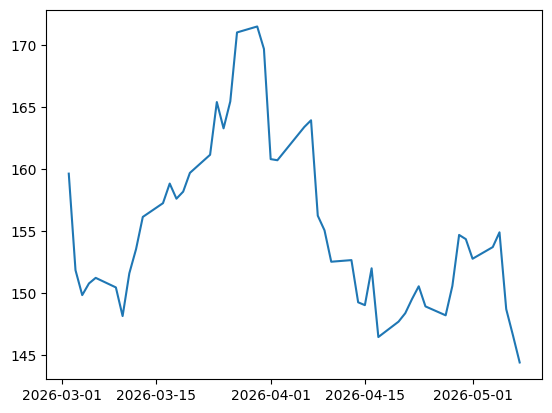

In [4]:
#backward sight
plt.plot(df.index, df['Price'])
plt.show()

In [5]:
INITIAL_PRICE=df.iloc[0,0]
SHARES=1_000
INITIAL_POSITION=-SHARES*INITIAL_PRICE
print(f"initial position is {INITIAL_POSITION:.2f}")

initial position is -159610.00


# Senario analysis

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Option params (fixed across all scenarios) ───────────────────
S0 = 159.61   # XOM entry price Mar 2, 2026
K  = 160.00   # ATM put strike
r  = 0.045    # risk-free rate
T  = 108/252  # days to Jun-18 expiry
N  = 100_000  # MC simulations
ask_paid = 2.29  # what you actually paid on Mar 2

print("Params loaded ✓")

Params loaded ✓


In [7]:
# ── 3 historical scenarios ────────────────────────────────────────
# Each window = event date ± 30 days
# We extract XOM's REAL μ and σ from that exact period
# Then use those params to simulate what could happen now

event_windows = {
    "Gulf War\n(Aug 1990)": {
        "start" : "1990-07-01",   # Iraq invaded Kuwait Aug 2
        "end"   : "1990-10-31",   # 4-month shock window
        "event" : "Iraq invaded Kuwait Aug 2, 1990\nOil $17 → $46",
        "color" : "#E53935",
        "ticker": "XOM"          # Exxon existed pre-merger
    },
    "Aramco Attack\n(Sep 2019)": {
        "start" : "2019-08-15",   # 30 days before attack Sep 14
        "end"   : "2019-10-15",   # 30 days after
        "event" : "Drone attack knocked out\n5% of global supply overnight",
        "color" : "#FF9800",
        "ticker": "XOM"
    },
    "Russia/Ukraine\n(Feb 2022)": {
        "start" : "2022-01-24",   # 30 days before invasion Feb 24
        "end"   : "2022-03-24",   # 30 days after
        "event" : "Russia invaded Ukraine\nOil $80 → $130, XOM $75 → $105",
        "color" : "#2196F3",
        "ticker": "XOM"
    },
}

print("Event windows:")
for name, w in event_windows.items():
    label = name.replace('\n', ' ')
    print(f"  {label:30s}  {w['start']}  →  {w['end']}")

Event windows:
  Gulf War (Aug 1990)             1990-07-01  →  1990-10-31
  Aramco Attack (Sep 2019)        2019-08-15  →  2019-10-15
  Russia/Ukraine (Feb 2022)       2022-01-24  →  2022-03-24


In [8]:
np.random.seed(42)

TRADING_DAYS = 252

scenario_params = {}
simulation_results = {}

for name, w in event_windows.items():
    ticker = w["ticker"]

    raw = yf.download(
        ticker,
        start=w["start"],
        end=w["end"],
        auto_adjust=True,
        progress=False
    )

    close = raw["Close"]

    # Fix possible DataFrame/Series issue from yfinance
    if isinstance(close, pd.DataFrame):
        close = close[ticker]

    close = close.dropna()

    ret = np.log(close / close.shift(1)).dropna()

    mu_daily = ret.mean()
    sigma_daily = ret.std()

    mu_annual = float(mu_daily * TRADING_DAYS)
    sigma_annual = float(sigma_daily * np.sqrt(TRADING_DAYS))

    price_start = float(close.iloc[0])
    price_end = float(close.iloc[-1])
    total_ret = float((price_end / price_start - 1) * 100)

    # Simulate terminal stock price
    Z = np.random.standard_normal(N)

    ST = S0 * np.exp(
        (mu_annual - 0.5 * sigma_annual ** 2) * T
        + sigma_annual * np.sqrt(T) * Z
    )

    scenario_params[name] = {
        "mu": mu_annual,
        "sigma": sigma_annual,
        "price_start": price_start,
        "price_end": price_end,
        "total_return": total_ret,
        "n_days": len(ret),
        "raw": raw,
    }

    simulation_results[name] = ST

    label = name.replace("\n", " ")

    print(
        f"{label:30s}  "
        f"μ={mu_annual*100:+.1f}%  "
        f"σ={sigma_annual*100:.1f}%  "
        f"XOM: ${price_start:.2f}→${price_end:.2f} "
        f"({total_ret:+.1f}%)  "
        f"n={len(ret)} days"
    )


Gulf War (Aug 1990)             μ=+10.3%  σ=24.2%  XOM: $3.63→$3.76 (+3.5%)  n=84 days
Aramco Attack (Sep 2019)        μ=+17.4%  σ=19.2%  XOM: $49.96→$51.39 (+2.9%)  n=41 days
Russia/Ukraine (Feb 2022)       μ=+88.4%  σ=38.5%  XOM: $62.73→$72.44 (+15.5%)  n=41 days


In [9]:
summary_rows = []

for name, ST in simulation_results.items():
    summary_rows.append({
        "Scenario": name.replace("\n", " "),
        "Mean ST": np.mean(ST),
        "Median ST": np.median(ST),
        "5% ST": np.percentile(ST, 5),
        "95% ST": np.percentile(ST, 95),
        "Prob ST < K": np.mean(ST < K),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.T


,0,1,2
Scenario,Gulf War (Aug 1990),Aramco Attack (Sep 2019),Russia/Ukraine (Feb 2022)
Mean ST,166.858624,171.978667,233.051191
Median ST,164.810001,170.618539,225.71111
5% ST,126.910616,138.830604,149.314395
95% ST,214.086262,209.743518,341.684042
Prob ST < K,0.42634,0.30398,0.08529


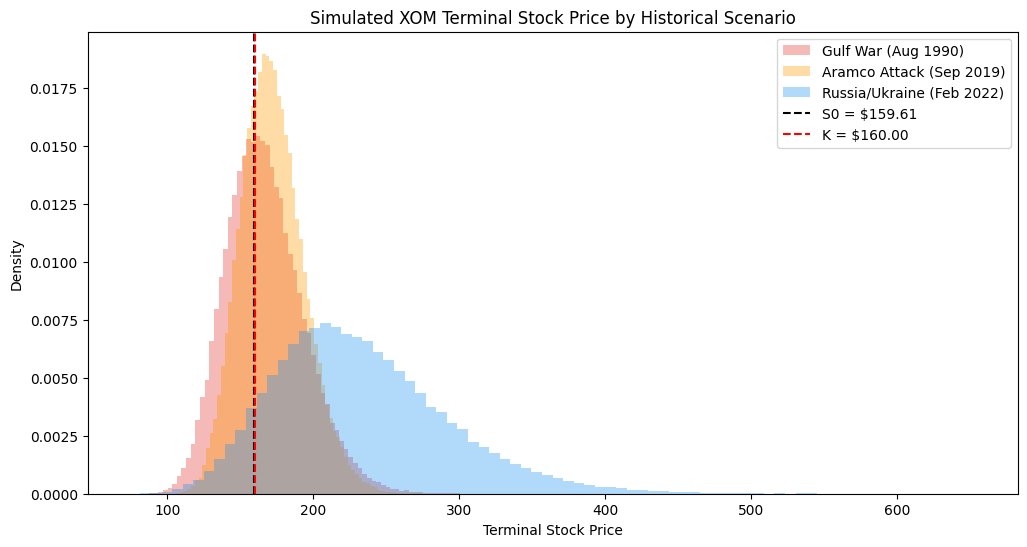

In [10]:
plt.figure(figsize=(12, 6))

for name, ST in simulation_results.items():
    plt.hist(
        ST,
        bins=80,
        alpha=0.35,
        density=True,
        label=name.replace("\n", " "),
        color=event_windows[name]["color"]
    )

plt.axvline(S0, color="black", linestyle="--", label=f"S0 = ${S0:.2f}")
plt.axvline(K, color="red", linestyle="--", label=f"K = ${K:.2f}")

plt.title("Simulated XOM Terminal Stock Price by Historical Scenario")
plt.xlabel("Terminal Stock Price")
plt.ylabel("Density")
plt.legend()
plt.show()


In [13]:
K_put = 155
K_call = 160

collar_rows = []

for name, ST in simulation_results.items():
    stock_payoff = ST
    put_payoff = np.maximum(K_put - ST, 0)
    short_call_payoff = -np.maximum(ST - K_call, 0)

    collar_payoff = stock_payoff + put_payoff + short_call_payoff

    collar_rows.append({
        "Scenario": name.replace("\n", " "),
        "Prob below put strike": np.mean(ST < K_put),
        "Prob between strikes": np.mean((ST >= K_put) & (ST <= K_call)),
        "Prob above call strike": np.mean(ST > K_call),
        "Mean collar payoff": np.mean(collar_payoff),
        "Median collar payoff": np.median(collar_payoff),
        "5% collar payoff": np.percentile(collar_payoff, 5),
        "95% collar payoff": np.percentile(collar_payoff, 95),
    })

collar_df = pd.DataFrame(collar_rows)
collar_df.T


,0,1,2
Scenario,Gulf War (Aug 1990),Aramco Attack (Sep 2019),Russia/Ukraine (Feb 2022)
Prob below put strike,0.35078,0.22255,0.06668
Prob between strikes,0.07556,0.08143,0.01861
Prob above call strike,0.57366,0.69602,0.91471
Mean collar payoff,158.056976,158.687309,159.62167
Median collar payoff,160.0,160.0,160.0
5% collar payoff,155.0,155.0,155.0
95% collar payoff,160.0,160.0,160.0


In [18]:
import numpy as np
import pandas as pd
import yfinance as yf

np.random.seed(42)

S0_stock = 159.61
S0_oil = 65.00

T = 108 / 252
N = 100_000
rho = 0.6

TRADING_DAYS = 252

oil_ticker = "CL=F"
gulf_oil_file = "data/oil_futures_price_GulfWar.xlsx"

scenario_results = {}

for name, w in event_windows.items():
    # XOM data
    xom_raw = yf.download(
        "XOM",
        start=w["start"],
        end=w["end"],
        auto_adjust=True,
        progress=False
    )

    xom_close = xom_raw["Close"]

    if isinstance(xom_close, pd.DataFrame):
        xom_close = xom_close["XOM"]

    xom_close = xom_close.dropna()
    xom_ret = np.log(xom_close / xom_close.shift(1)).dropna()

    mu_stock = float(xom_ret.mean() * TRADING_DAYS)
    sigma_stock = float(xom_ret.std() * np.sqrt(TRADING_DAYS))

    # Oil futures data
    if "Gulf War" in name:
        oil_raw = pd.read_excel(gulf_oil_file)

        oil_raw["Date"] = pd.to_datetime(oil_raw["Date"])
        oil_raw = oil_raw.sort_values("Date")

        oil_close = oil_raw["LastPrice"].astype(float).dropna()

    else:
        oil_raw = yf.download(
            oil_ticker,
            start=w["start"],
            end=w["end"],
            auto_adjust=True,
            progress=False
        )

        oil_close = oil_raw["Close"]

        if isinstance(oil_close, pd.DataFrame):
            oil_close = oil_close[oil_ticker]

        oil_close = oil_close.dropna()

    oil_ret = np.log(oil_close / oil_close.shift(1)).dropna()

    mu_oil = float(oil_ret.mean() * TRADING_DAYS)
    sigma_oil = float(oil_ret.std() * np.sqrt(TRADING_DAYS))

    # Correlated random shocks using Cholesky
    corr_matrix = np.array([
        [1.0, rho],
        [rho, 1.0]
    ])

    L = np.linalg.cholesky(corr_matrix)

    Z = np.random.standard_normal((2, N))
    Z_corr = L @ Z

    Z_stock = Z_corr[0]
    Z_oil = Z_corr[1]

    # Simulate terminal prices
    ST_stock = S0_stock * np.exp(
        (mu_stock - 0.5 * sigma_stock ** 2) * T
        + sigma_stock * np.sqrt(T) * Z_stock
    )

    ST_oil = S0_oil * np.exp(
        (mu_oil - 0.5 * sigma_oil ** 2) * T
        + sigma_oil * np.sqrt(T) * Z_oil
    )

    simulated_corr = np.corrcoef(
        np.log(ST_stock / S0_stock),
        np.log(ST_oil / S0_oil)
    )[0, 1]

    scenario_results[name] = {
        "mu_stock": mu_stock,
        "sigma_stock": sigma_stock,
        "mu_oil": mu_oil,
        "sigma_oil": sigma_oil,
        "ST_stock": ST_stock,
        "ST_oil": ST_oil,
        "simulated_corr": simulated_corr,
    }

    print(name.replace("\n", " "))
    print(f"  XOM μ={mu_stock*100:+.2f}%  σ={sigma_stock*100:.2f}%")
    print(f"  Oil μ={mu_oil*100:+.2f}%  σ={sigma_oil*100:.2f}%")
    print(f"  Simulated corr={simulated_corr:.4f}")
    print(f"  Mean XOM ST=${np.mean(ST_stock):.2f}")
    print(f"  Mean Oil ST=${np.mean(ST_oil):.2f}")
    print()


Gulf War (Aug 1990)
  XOM μ=+10.32%  σ=24.25%
  Oil μ=+186.31%  σ=74.22%
  Simulated corr=0.6040
  Mean XOM ST=$166.86
  Mean Oil ST=$144.60

Aramco Attack (Sep 2019)
  XOM μ=+17.39%  σ=19.20%
  Oil μ=-10.01%  σ=45.89%
  Simulated corr=0.5960
  Mean XOM ST=$171.93
  Mean Oil ST=$62.24

Russia/Ukraine (Feb 2022)
  XOM μ=+88.42%  σ=38.47%
  Oil μ=+197.76%  σ=63.52%
  Simulated corr=0.6013
  Mean XOM ST=$232.80
  Mean Oil ST=$151.45



In [21]:
S0_stock = 159.61
F0_oil = 69.81

stock_shares = 1000
num_contracts = 2
contract_size = 1000

hedged_pnl_rows = []

for name, result in scenario_results.items():
    ST_stock = result["ST_stock"]
    ST_oil = result["ST_oil"]

    stock_pnl = (ST_stock - S0_stock) * stock_shares
    oil_futures_pnl = (ST_oil - F0_oil) * contract_size * num_contracts

    total_hedged_pnl = stock_pnl - oil_futures_pnl

    hedged_pnl_rows.append({
        "Scenario": name.replace("\n", " "),

        "Mean ST Stock": np.mean(ST_stock),
        "Mean ST Oil": np.mean(ST_oil),

        "Mean Stock PnL": np.mean(stock_pnl),
        "Mean Oil Futures PnL": np.mean(oil_futures_pnl),
        "Mean Total Hedged PnL": np.mean(total_hedged_pnl),

        "Median Total Hedged PnL": np.median(total_hedged_pnl),
        "5% Total Hedged PnL": np.percentile(total_hedged_pnl, 5),
        "95% Total Hedged PnL": np.percentile(total_hedged_pnl, 95),

        "Prob Profit": np.mean(total_hedged_pnl > 0),
        "Prob Loss": np.mean(total_hedged_pnl < 0),
    })

hedged_pnl_df = pd.DataFrame(hedged_pnl_rows)

money_cols = [
    "Mean ST Stock",
    "Mean ST Oil",
    "Mean Stock PnL",
    "Mean Oil Futures PnL",
    "Mean Total Hedged PnL",
    "Median Total Hedged PnL",
    "5% Total Hedged PnL",
    "95% Total Hedged PnL",
]

hedged_pnl_df[money_cols] = hedged_pnl_df[money_cols].round(2)

hedged_pnl_df.T


,0,1,2
Scenario,Gulf War (Aug 1990),Aramco Attack (Sep 2019),Russia/Ukraine (Feb 2022)
Mean ST Stock,166.86,171.93,232.8
Mean ST Oil,144.6,62.24,151.45
Mean Stock PnL,7248.62,12317.43,73193.65
Mean Oil Futures PnL,149583.69,-15144.45,163284.92
Mean Total Hedged PnL,-142335.07,27461.88,-90091.27
Median Total Hedged PnL,-111852.76,30931.41,-70610.11
5% Total Hedged PnL,-398694.7,-28504.96,-292089.48
95% Total Hedged PnL,11431.34,71146.91,46379.22
Prob Profit,0.07806,0.83083,0.18217


# hedging

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ── Parameters ────────────────────────────────────────
START_DATE  = "2024-01-01"
END_DATE    = "2026-02-28"   # geopolitical shock date

# XOM, S&P 500 ETF, Energy ETF, WTI Crude Oil front-month futures
tickers = ["XOM", "SPY", "XLE", "CL=F"]

raw = yf.download(tickers, start=START_DATE, end=END_DATE,
                  auto_adjust=True)["Close"]
raw.columns = ["XOM", "SPY", "XLE", "OIL"]
raw.dropna(inplace=True)

# Daily log returns
returns = np.log(raw / raw.shift(1)).dropna()

print(f"Date range : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Observations: {len(returns)}")
raw.tail(3)

[*********************100%***********************]  4 of 4 completed

Date range : 2024-01-03 → 2026-02-27
Observations: 540


,XOM,SPY,XLE,OIL
Date,,,,
2026-02-25,65.419998,691.262207,54.513821,149.059998
2026-02-26,65.209999,687.422607,54.692654,148.539993
2026-02-27,67.019997,684.121643,55.557003,152.500000


In [ ]:
# ── Regression 1: Simple — XOM ~ Oil Price ────────────
# Purpose: get clean oil beta for WTI futures hedge ratio

X1     = sm.add_constant(returns["OIL"])
y      = returns["XOM"]
model1 = sm.OLS(y, X1).fit()

print(model1.summary())

beta_oil_simple = model1.params["OIL"]
print(f"\n→ Oil Beta (β₃) : {beta_oil_simple:.4f}")
print(f"→ Meaning       : 1% move in WTI → {beta_oil_simple*100:.2f}bp move in XOM")

                            OLS Regression Results                            
Dep. Variable:                    XOM   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     298.3
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.69e-53
Time:                        00:41:37   Log-Likelihood:                 1485.1
No. Observations:                 540   AIC:                            -2966.
Df Residuals:                     538   BIC:                            -2958.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.001     -1.219      0.2

In [ ]:
# ── Regression 2: Full — XOM ~ Market + Oil ───────────
# Purpose: decompose risk into market beta vs oil beta
# (XLE dropped — multicollinear with OIL, see Cell 5)

X2     = sm.add_constant(returns[["SPY", "OIL"]])
model2 = sm.OLS(y, X2).fit()

print(model2.summary())

beta_mkt = model2.params["SPY"]
beta_oil = model2.params["OIL"]
print(f"\n→ Market Beta (β₁): {beta_mkt:.4f}  ← broad equity risk")
print(f"→ Oil Beta    (β₃): {beta_oil:.4f}  ← energy/commodity risk")

                            OLS Regression Results                            
Dep. Variable:                    XOM   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     149.1
Date:                Fri, 08 May 2026   Prob (F-statistic):           3.17e-52
Time:                        00:41:37   Log-Likelihood:                 1485.3
No. Observations:                 540   AIC:                            -2965.
Df Residuals:                     537   BIC:                            -2952.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.001     -1.185      0.2

In [ ]:
# ── Multicollinearity check ────────────────────────────
# Justifies dropping XLE from the full regression

corr = returns[["XOM", "SPY", "OIL", "XLE"]].corr().round(3)
print("Correlation matrix:\n", corr)

print(f"\nCorr(OIL, XLE) = {corr.loc['OIL','XLE']:.3f}",
      "← high: justifies dropping XLE")
print(f"Corr(OIL, SPY) = {corr.loc['OIL','SPY']:.3f}")

Correlation matrix:
        XOM    SPY    OIL    XLE
XOM  1.000  0.159  0.597  0.601
SPY  0.159  1.000  0.296  0.499
OIL  0.597  0.296  1.000  0.895
XLE  0.601  0.499  0.895  1.000

Corr(OIL, XLE) = 0.895 ← high: justifies dropping XLE
Corr(OIL, SPY) = 0.296


In [ ]:
# ── WTI Futures Hedge Ratio ────────────────────────────
# 1 WTI contract = 1,000 barrels

xom_price    = raw["XOM"].iloc[-1]
oil_price    = raw["OIL"].iloc[-1]
n_shares     = int(1_000)
port_value   = xom_price * n_shares
contract_sz  = int(1_000)          # barrels per futures contract

# Dollar oil exposure = beta_oil * portfolio_value
# Contracts to short  = dollar_exposure / (oil_price * contract_size)
dollar_oil_exp = beta_oil_simple * port_value
n_contracts    = dollar_oil_exp / (oil_price * contract_sz)

print(f"XOM price (Feb 28 2026) : ${xom_price:.2f}")
print(f"Portfolio value         : ${port_value:,.2f}")
print(f"WTI oil price           : ${oil_price:.2f}/bbl")
print(f"\nOil beta (β₃ simple)    : {beta_oil_simple:.4f}")
print(f"Dollar oil exposure     : ${dollar_oil_exp:,.2f}")
print(f"WTI contracts to SHORT  : {n_contracts:.2f}  → round to {round(n_contracts)}")

XOM price (Feb 28 2026) : $67.02
Portfolio value         : $67,020.00
WTI oil price           : $152.50/bbl

Oil beta (β₃ simple)    : 0.8226
Dollar oil exposure     : $55,130.24
WTI contracts to SHORT  : 0.36  → round to 0


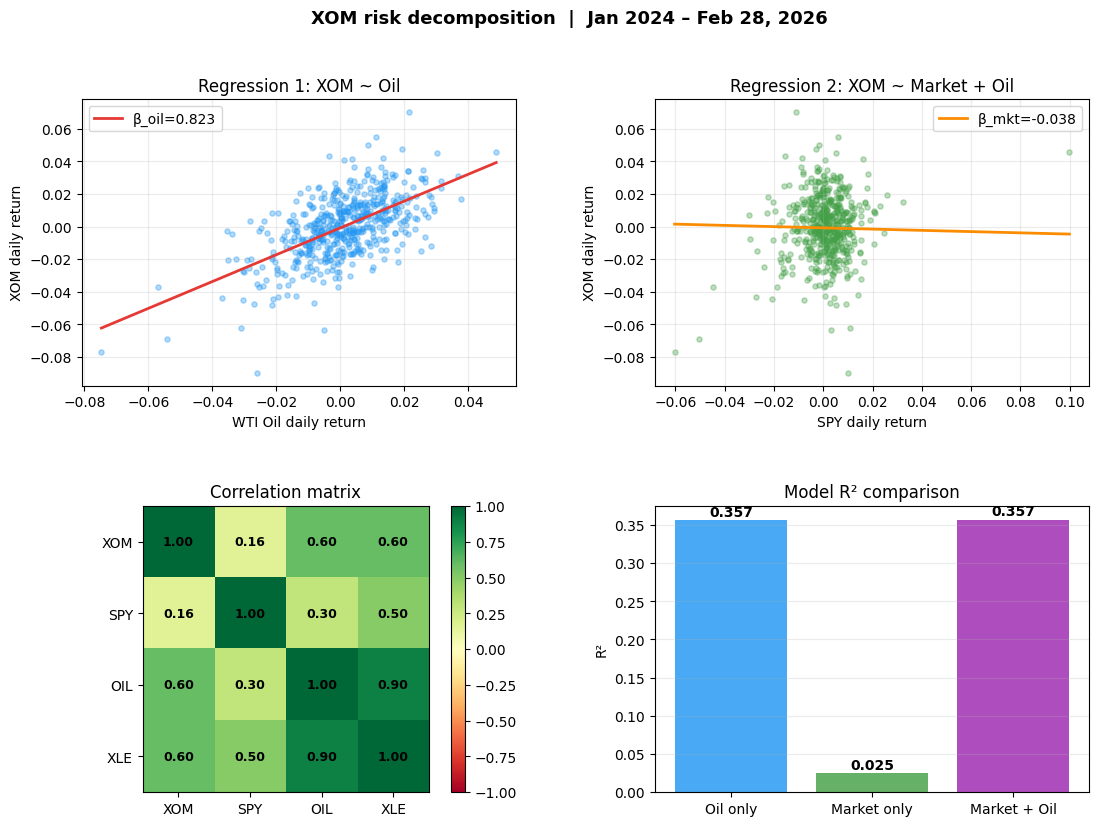

In [ ]:
fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# Panel 1 — XOM vs OIL scatter + regression line
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(returns["OIL"], returns["XOM"], alpha=0.35, s=14, color="#2196F3")
xl = np.linspace(returns["OIL"].min(), returns["OIL"].max(), 100)
ax1.plot(xl, model1.params["const"] + model1.params["OIL"] * xl,
        color="#E53935", lw=2, label=f"β_oil={beta_oil_simple:.3f}")
ax1.set_xlabel("WTI Oil daily return"); ax1.set_ylabel("XOM daily return")
ax1.set_title("Regression 1: XOM ~ Oil"); ax1.legend(); ax1.grid(alpha=0.25)

# Panel 2 — XOM vs SPY scatter
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(returns["SPY"], returns["XOM"], alpha=0.35, s=14, color="#43A047")
xl2 = np.linspace(returns["SPY"].min(), returns["SPY"].max(), 100)
ax2.plot(xl2, model2.params["const"] + model2.params["SPY"] * xl2,
        color="#FB8C00", lw=2, label=f"β_mkt={beta_mkt:.3f}")
ax2.set_xlabel("SPY daily return"); ax2.set_ylabel("XOM daily return")
ax2.set_title("Regression 2: XOM ~ Market + Oil"); ax2.legend(); ax2.grid(alpha=0.25)

# Panel 3 — Correlation heatmap
ax3 = fig.add_subplot(gs[1, 0])
labels4 = ["XOM", "SPY", "OIL", "XLE"]
cm4 = returns[labels4].corr()
im = ax3.imshow(cm4, cmap="RdYlGn", vmin=-1, vmax=1)
ax3.set_xticks(range(4)); ax3.set_yticks(range(4))
ax3.set_xticklabels(labels4); ax3.set_yticklabels(labels4)
for i in range(4):
    for j in range(4):
        ax3.text(j, i, f"{cm4.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=9, fontweight="bold")
ax3.set_title("Correlation matrix"); plt.colorbar(im, ax=ax3)

# Panel 4 — R² comparison bar chart
ax4 = fig.add_subplot(gs[1, 1])
r2_oil = model1.rsquared
r2_mkt = sm.OLS(y, sm.add_constant(returns["SPY"])).fit().rsquared
r2_full= model2.rsquared
bars = ax4.bar(["Oil only", "Market only", "Market + Oil"],
               [r2_oil, r2_mkt, r2_full],
               color=["#2196F3", "#43A047", "#9C27B0"], alpha=0.82)
for b, v in zip(bars, [r2_oil, r2_mkt, r2_full]):
    ax4.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
            ha="center", fontweight="bold", fontsize=10)
ax4.set_ylabel("R²"); ax4.set_title("Model R² comparison"); ax4.grid(alpha=0.25, axis="y")

fig.suptitle("XOM risk decomposition  |  Jan 2024 – Feb 28, 2026",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

XOM's risk is almost entirely oil risk